# Maximum Likelihood Fit of Exponential Background + Gaussian Signal
**ML4HEP Statistics Tutorial**

- Generate pseudo-data
- Build a binned Poisson likelihood
- Fit Higgs mass and coupling
- Visualize likelihood scans

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import minimize

np.random.seed(42)


## Physics model

In [15]:
# True parameters
m_true=125.0
sigma=1.5
kappa_true=1.0
Ns_SM=300
#Ns_SM=50
Ns_true=kappa_true**2*Ns_SM
Nb_true=2500
lam=0.03

xmin,xmax=100,150
bins=np.linspace(xmin,xmax,51)
centers=0.5*(bins[:-1]+bins[1:])
bw=bins[1]-bins[0]

PARAM_NAMES = ['m_H (GeV)', 'κ',  'N_b']

# PDFs
def gauss_pdf(x,m,s):
    return norm.pdf(x,m,s)

def exp_pdf(x,l):
    y=np.exp(-l*(x-xmin))
    return y/np.trapz(y,x)


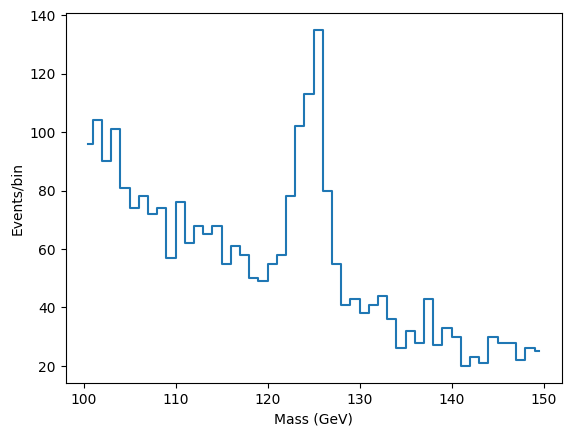

In [16]:
# Generate pseudo-data
sig=np.random.normal(m_true,sigma,int(Ns_true))

u=np.random.rand(int(Nb_true))
bkg=xmin-np.log(1-u*(1-np.exp(-lam*(xmax-xmin))))/lam

data=np.concatenate([sig,bkg])
counts,_=np.histogram(data,bins)

plt.step(centers,counts,where='mid')
plt.xlabel("Mass (GeV)")
plt.ylabel("Events/bin")
plt.show()


## Binned Poisson likelihood

/tmp/ipykernel_2623/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


Best fit mass   = 124.78581030233272
Best fit kappa  = 1.022869763001836
Best fit Nb     = 2400.008990158831


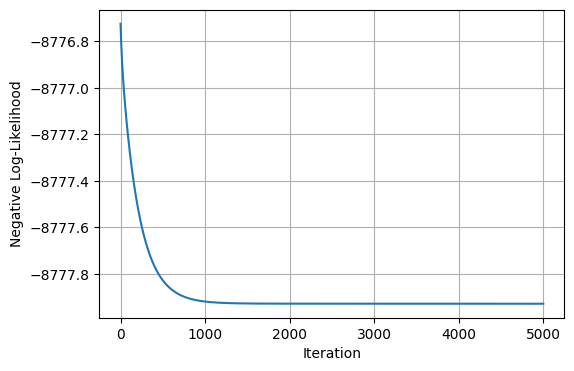

In [17]:
def expected(par):
    m,kappa,Nb=par
    Ns=kappa**2*Ns_SM
    s=gauss_pdf(centers,m,sigma)
    s=s/np.sum(s)
    b=exp_pdf(centers,lam)
    b=b/np.sum(b)
    mu=Ns*s+Nb*b
    return mu


def nll(par):
    mu=expected(par)
    mu=np.clip(mu,1e-9,None)
    return np.sum(mu-counts*np.log(mu))



def nll_minuit(m,kappa,Nb):
    par = (m, kappa, Nb)     
    mu=expected(par)
    mu=np.clip(mu,1e-9,None)
    return np.sum(mu-counts*np.log(mu))



# Numerical gradient

def numerical_gradient(fun, x, h=1e-5):

    grad = np.zeros(len(x))

    for i in range(len(x)):

        xp = x.copy()
        xm = x.copy()

        xp[i] += h
        xm[i] -= h

        grad[i] = (fun(*xp) - fun(*xm)) / (2*h)

    return grad



# Gradient Descent

def gradient_descent(fun,
                     x0,
                     learning_rate=1e-4,
                     max_iter=5000,
                     tolerance=1e-6):

    x = np.array(x0, dtype=float)

    history = []

    for iteration in range(max_iter):

        grad = numerical_gradient(fun, x)

        x_new = x - learning_rate * grad

        history.append(fun(*x_new))

        # convergence test
        if np.linalg.norm(x_new - x) < tolerance:
            print("Converged after", iteration, "iterations")
            break

        x = x_new

    return x, history


x0 = [125, 1.0, 2400]

bestfit, history = gradient_descent(
                    nll_minuit,
                    x0,
                    learning_rate=5e-5)

mhat, khat, nbhat = bestfit

print("Best fit mass   =", mhat)
print("Best fit kappa  =", khat)
print("Best fit Nb     =", nbhat)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history)

plt.xlabel("Iteration")
plt.ylabel("Negative Log-Likelihood")

plt.grid(True)

plt.show()








## Numerical Hessian

We compute the Hessian by finite differences around the best-fit point.

At the minimum, the Hessian of $-\ln\mathcal{L}$ approximates the inverse covariance (Fisher information):

$$
H_{ij} = \frac{\partial^2(-\ln\mathcal{L})}{\partial\theta_i\partial\theta_j}\bigg|_{\hat\theta}, \qquad \Sigma = H^{-1}
$$

In [18]:
def numerical_hessian(fun,x,h=1e-3):

    n=len(x)
    H=np.zeros((n,n))

    for i in range(n):
        for j in range(n):

            xp=x.copy()
            xm=x.copy()
            xpp=x.copy()
            xmm=x.copy()

            xp[i]+=h
            xp[j]-=h

            xm[i]-=h
            xm[j]+=h

            xpp[i]+=h
            xpp[j]+=h

            xmm[i]-=h
            xmm[j]-=h

            H[i,j]=(fun(xpp)-fun(xp)-fun(xm)+fun(xmm))/(4*h*h)

    return H

theta=[mhat, khat, nbhat]
H=numerical_hessian(nll,theta)

print(H)


COV = np.linalg.inv(H)
print(COV)
ERR = np.sqrt(np.abs(np.diag(COV)))

print(f"{'Parameter':<14}  {'Value':>10}  {'Uncertainty':>12}")
print('-'*40)
for name, v, e in zip(PARAM_NAMES, theta, ERR):
    print(f"{name:<14}  {v:>10.4f}  ±{e:>10.4f}")

eigvals = np.linalg.eigvalsh(H)

#print(f"\nHessian eigenvalues: {np.round(eigvals,4)}")

[[ 4.81680040e+01  6.09083372e+00 -1.29739419e-03]
 [ 6.09083372e+00  6.50074482e+02  1.17187028e-01]
 [-1.29739419e-03  1.17187028e-01  4.06998879e-04]]
[[ 2.07917210e-02 -2.18073448e-04  1.29067769e-01]
 [-2.18073448e-04  1.62478713e-03 -4.68519479e-01]
 [ 1.29067769e-01 -4.68519479e-01  2.59232128e+03]]
Parameter            Value   Uncertainty
----------------------------------------
m_H (GeV)         124.7858  ±    0.1442
κ                   1.0229  ±    0.0403
N_b              2400.0090  ±   50.9148


/tmp/ipykernel_2623/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


/tmp/ipykernel_2623/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


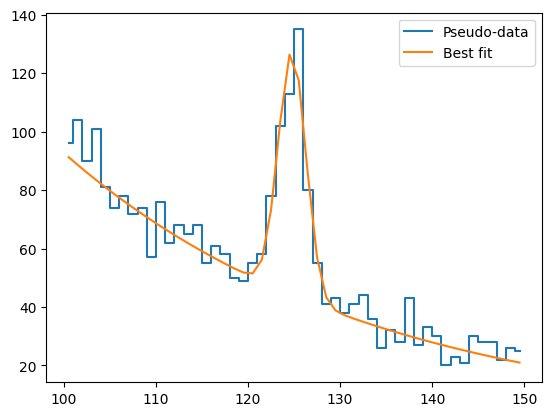

In [19]:
mu = expected(theta)
plt.step(centers,counts,where='mid',label='Pseudo-data')
plt.plot(centers,mu,label='Best fit')
plt.legend()
plt.show()


## 1D Likelihood scan in mass for best values of kappa and Nb

/tmp/ipykernel_2623/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


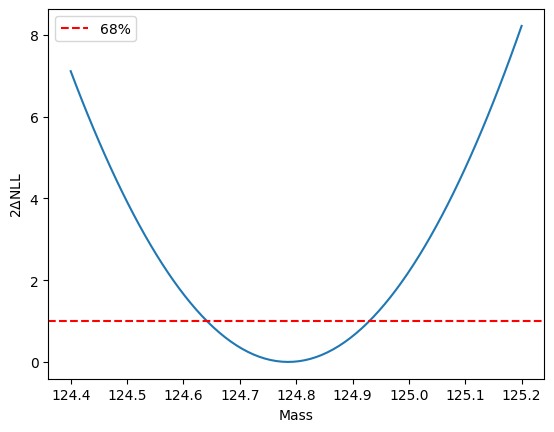

In [20]:
mscan=np.linspace(124.4,125.2,80)
vals=[]


par = (mhat, khat, nbhat) 

for m in mscan:
    #vals.append(nll([m,khat,nbhat])-nll(res.x))
    vals.append(nll([m,khat,nbhat])-nll(par))
    #print(nll([m,khat,nbhat])-nll(res.x)) 

plt.plot(mscan,2*np.array(vals))
plt.axhline(1,color='r',ls='--',label='68%')
plt.xlabel("Mass")
plt.ylabel(r"$2\Delta$NLL")
plt.legend()
plt.show()


# Exercises

1. Double the luminosity (increase Ns_true and Nb_true).
2. Reduce the detector resolution.
3. Change kappa_true to 0.5.
4. Add a Crystal Ball signal model instead of a Gaussian.
5. Make a 2D likelihood scan in (mass, kappa).


### Do a 1D likelihood scan in kappa

/tmp/ipykernel_2623/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


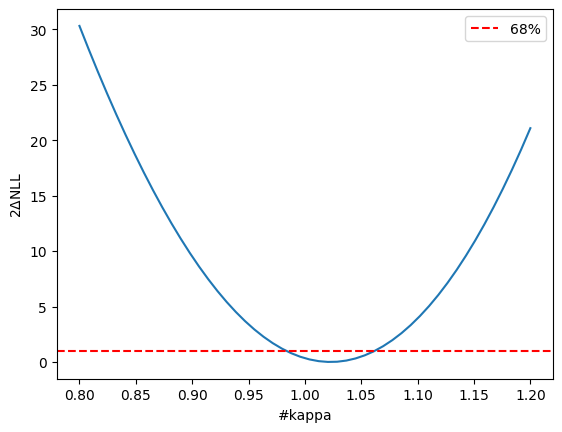

In [21]:
#kscan=np.linspace(0,2,50)
kscan=np.linspace(0.8,1.2,50)

vals=[]


par = (mhat, khat, nbhat) 

for k in kscan:
    #vals.append(nll([mhat,k,nbhat])-nll(res.x))
    vals.append(nll([mhat,k,nbhat])-nll(par))

plt.plot(kscan,2*np.array(vals))
plt.axhline(1,color='r',ls='--',label='68%')
plt.xlabel("#kappa")
plt.ylabel(r"$2\Delta$NLL")
plt.legend()
plt.show()

### 2D likelihood scan

/tmp/ipykernel_2623/935444425.py:24: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return y/np.trapz(y,x)


'\nlevels = [2.30, 5.99]\n\ncs = plt.contour(\n    K,\n    M,\n    deltaNLL,\n    levels=levels,\n    colors=["red", "white"],\n    linewidths=2\n)\n\nplt.clabel(cs, fmt={\n    2.30: "68%",\n    5.99: "95%"\n})\n\nplt.plot(\n    res.x[1],      # kappa\n    res.x[0],      # mass\n    "r*",\n    markersize=15,\n    label="Best fit"\n)\n'

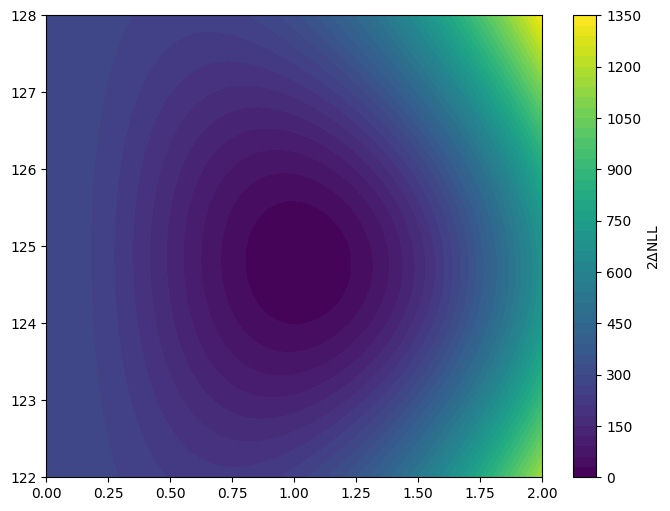

In [22]:
import numpy as np
import matplotlib.pyplot as plt

# Scan ranges
kscan = np.linspace(0, 2, 50)
mscan = np.linspace(122, 128, 80)

# Meshgrid
K, M = np.meshgrid(kscan, mscan)

# Allocate array
deltaNLL = np.zeros_like(K)

# Best-fit NLL
#nll_best = nll(res.x)



par = (mhat, khat, nbhat) 

nll_best = nll(par)

# Fill grid
for i, m in enumerate(mscan):
    for j, k in enumerate(kscan):
        deltaNLL[i, j] = 2*(nll([m, k, nbhat]) - nll_best)

plt.figure(figsize=(8,6))

cf = plt.contourf(
    K,
    M,
    deltaNLL,
    levels=50,
    cmap="viridis"
)

plt.colorbar(cf, label=r"$2\Delta\mathrm{NLL}$")

'''
levels = [2.30, 5.99]

cs = plt.contour(
    K,
    M,
    deltaNLL,
    levels=levels,
    colors=["red", "white"],
    linewidths=2
)

plt.clabel(cs, fmt={
    2.30: "68%",
    5.99: "95%"
})

plt.plot(
    res.x[1],      # kappa
    res.x[0],      # mass
    "r*",
    markersize=15,
    label="Best fit"
)
'''